<a href="https://colab.research.google.com/github/marcopeduto/marcopeduto/blob/main/Copie_de_Assignment_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSML investigation:
### You are part of the Suisse Impossible Mission Force, or SIMF for short. You need to uncover a rogue agent that is trying to steal sensitive information.

### Your mission, should you choose to accept it, is to find that agent before any classified information gets stolen. Good luck!


## Assignment part one

Airport security confiscated a laptop of a spy, which was later given to you. The laptop contains some documents that might be useful in the investigation process. You retrieve those documents and want to analyse them. Our intelligence shows that the person that we are looking for has visited the USA between Sept 2019 to Oct 2020. He is currently working undercover.


### Getting to know our data

We have retrieved from the laptop the following file:
- A list of suspects
- The flight records of these potential suspects



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
userRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignments/Part%201/data/userRecords.csv")
travelRecords = pd.read_csv("https://raw.githubusercontent.com/michalis0/DataScience_and_MachineLearning/refs/heads/master/Assignments/Part%201/data/flightRecords.csv")

In [ ]:
userRecords

,UserID,first_name,last_name,birthday,country,marital_status,number_of_kids,employment
0,317991,Lu***,Al*****,29.07.03,AR,1,2.0,Web Designer
1,241892,Ma****,Ro*******,10.11.99,AR,1,0.0,Banker
2,303376,Fr****,Ac****,25.07.84,AR,1,0.0,Kitchen staff
3,761992,Fr****,Go***,20.03.70,AR,1,0.0,Teaching Assistant
4,373318,Jo***,Ro***,05.10.71,AR,1,0.0,Administrative employee
...,...,...,...,...,...,...,...,...
952,218415,Bu******,Mo******,22.01.01,ZA,0,1.0,Web Designer
953,173906,Th*****,Mo******,06.11.61,ZA,0,2.0,Web Designer
954,178685,Mi*****,Bu*******,29.05.53,ZA,0,1.0,Professor
955,200865,Si*******,Na****,16.12.62,ZA,0,0.0,Web Designer


In [ ]:
travelRecords[travelRecords["userID"] == 317991]

,flightName,departure,destination,date,userID
0,KX65826,AR,IT,20.01.10,317991
1,CL12336,IT,MT,16.06.10,317991
2,YN106988,MT,SE,08.05.11,317991
3,CB58289,SE,EE,08.11.11,317991
4,SX625101,EE,AZ,17.11.11,317991
5,FI81778,AZ,ES,19.01.12,317991
6,WL73165,ES,RU,24.02.12,317991
7,NG103876,RU,JP,28.06.12,317991
8,IX62714,JP,AT,24.07.12,317991
9,BT46823,AT,GB,25.08.12,317991


#### Shape of the data

Let's first check how many rows and columns (features) are in the user records

In [ ]:
print(userRecords.shape)

(957, 8)


**Q1. How many rows are there in the user records dataset?**

In [ ]:
print(userRecords.shape[0])

957



#### Check out the first few rows
Print the first few rows of the user records dataset and check them. Note that to protect innocent people, the name of the suspects have been censored, those will be revealed once number of potential suspects decreases.


In [ ]:
print(userRecords.head())

   UserID first_name  last_name  birthday country marital_status  \
0  317991      Lu***    Al*****  29.07.03      AR              1   
1  241892     Ma****  Ro*******  10.11.99      AR              1   
2  303376     Fr****     Ac****  25.07.84      AR              1   
3  761992     Fr****      Go***  20.03.70      AR              1   
4  373318      Jo***      Ro***  05.10.71      AR              1   

   number_of_kids               employment  
0             2.0             Web Designer  
1             0.0                   Banker  
2             0.0            Kitchen staff  
3             0.0       Teaching Assistant  
4             0.0  Administrative employee  


#### Column/feature names
print the list of columns in the user records dataset.

In [ ]:
print(userRecords.columns)

Index(['UserID', 'first_name', 'last_name', 'birthday', 'country',
       'marital_status', 'number_of_kids', 'employment'],
      dtype='object')


#### Duplicates
Check if there are any duplicate entries in the user records dataset.

__Remark__: If there are two rows in the dataset that have the same value for __all of the columns__, we consider this as a duplicate.

In [ ]:
print(userRecords.duplicated())
print(userRecords.duplicated().sum())


0      False
1      False
2      False
3      False
4      False
       ...  
952    False
953    False
954    False
955    False
956    False
Length: 957, dtype: bool
3


Show all the duplicated rows in the user records dataset.

__Hint:__ use the method `duplicated(keep=False)` to get all occurrences of the duplicated rows.

In [ ]:
print(userRecords[userRecords.duplicated(keep=False)])

     UserID first_name last_name  birthday country marital_status  \
18   100684    Ma*****    Me****  17.06.76      AR            NaN   
19   100684    Ma*****    Me****  17.06.76      AR            NaN   
47   910382      Ni***    El****  21.03.75      AZ            NaN   
165  910382      Ni***    El****  21.03.75      AZ            NaN   
276  610518    An*****  An******  15.02.53      DK              1   
290  610518    An*****  An******  15.02.53      DK              1   

     number_of_kids               employment  
18              0.0  Administrative employee  
19              0.0  Administrative employee  
47              0.0  Administrative employee  
165             0.0  Administrative employee  
276             NaN                  Manager  
290             NaN                  Manager  


**Q2. Are there any duplicate entries in the user records dataset?**

*Note: Duplicate entries refer to two or more rows where all the values across every column are identical.*

In [ ]:
print(userRecords.duplicated().sum())

3


**Q3. How many duplicate entries are in the user records dataset?**

(Remark: for instance: there are 2 duplicate "entries" in the following list: '1 ,2, 1, 3, 3, 4, 5'. It's 1 and 3).

In [ ]:
print(userRecords.duplicated().sum())

3


Drop the duplicate entries in the user records dataset.

In [ ]:
userRecords = userRecords.drop_duplicates()
print(userRecords.duplicated().sum())

0


### Spies often use false identities with fabricated data.

#### This suggests that if certain data points occur with statistically improbable frequency, they might be fabricated.

In this part we are going to verify if there are birthdates that have been reused an unusual amount of times.

Let's first ensure that the birthday column in the user records dataset has the correct format (datetime):


In [ ]:
#Your code here
print(userRecords.dtypes)

UserID              int64
first_name         object
last_name          object
birthday           object
country            object
marital_status     object
number_of_kids    float64
employment         object
dtype: object


Convert the column `birthday` to datetime if necessary

In [ ]:
#Your code here
print(userRecords["birthday"].value_counts())

birthday
01.06.92    4
06.04.70    2
26.03.54    2
15.03.83    2
23.06.60    2
           ..
29.12.99    1
14.01.72    1
08.01.87    1
13.11.62    1
14.06.96    1
Name: count, Length: 929, dtype: int64


Find the list of birthdays that are duplicated/reused in the dataset

In [ ]:
#Your code here
birthday_counts = userRecords["birthday"].value_counts()
print(birthday_counts[birthday_counts > 1])

birthday
01.06.92    4
06.04.70    2
26.03.54    2
15.03.83    2
23.06.60    2
22.09.68    2
25.06.57    2
24.12.57    2
02.12.91    2
26.03.60    2
12.09.99    2
09.08.99    2
09.10.68    2
07.07.62    2
08.01.55    2
18.03.70    2
28.01.75    2
26.08.83    2
24.07.67    2
21.11.78    2
18.12.57    2
30.11.04    2
Name: count, dtype: int64


Let's count how many people have their birthday on the same day among the duplicated birthdays.

In [ ]:
#Your code here
print(birthday_counts[birthday_counts > 1].sum())

46


**Q4. What is the most common birthday in the dataset?**

In [ ]:
print(userRecords["birthday"].value_counts().idxmax())

01.06.92


**Q5. How many users have their birthdays on that day (the most common birthday)?**

In [ ]:
print(userRecords["birthday"].value_counts().max())

4


We can consider that there is no suspicious discrepancy through birthdays.


#### We have reasons to believe that the suspect works very thoroughly, so he would make sure that the fabricated data about his identity is complete in order for his operation to run smoothly.
#### Therefore, we can exclude the people with incomplete information from the list of potential suspects.

Count how many null values are there in each column of the user records dataset. You can call `isnull()` and `sum()` to get a count of how many null values are there in each column.

In [ ]:
#Your code here
print(userRecords.isnull().sum())

UserID              0
first_name          1
last_name           1
birthday            1
country             0
marital_status    102
number_of_kids    152
employment          1
dtype: int64


If you encounter any null values in the dataset, be sure to exclude those entries from the suspect list.

In [ ]:
#Your code here
userRecords = userRecords.dropna()
print(userRecords.isnull().sum())

UserID            0
first_name        0
last_name         0
birthday          0
country           0
marital_status    0
number_of_kids    0
employment        0
dtype: int64


### Linking the user records to the flight records

We will now proceed to identify the users who were in the USA from Sept 1st, 2019 to Oct 31st, 2020.

We will merge the flight records with the user records in order to ensure that users who have been unsuspected in the previous step are not considered.

In [ ]:
#check the user records dataset
print(userRecords)

     UserID  first_name  last_name  birthday country marital_status  \
0    317991       Lu***    Al*****  29.07.03      AR              1   
1    241892      Ma****  Ro*******  10.11.99      AR              1   
2    303376      Fr****     Ac****  25.07.84      AR              1   
3    761992      Fr****      Go***  20.03.70      AR              1   
4    373318       Jo***      Ro***  05.10.71      AR              1   
..      ...         ...        ...       ...     ...            ...   
950  458293  No********   Wi******  26.03.54      ZA              1   
952  218415    Bu******   Mo******  22.01.01      ZA              0   
953  173906     Th*****   Mo******  06.11.61      ZA              0   
954  178685     Mi*****  Bu*******  29.05.53      ZA              0   
955  200865   Si*******     Na****  16.12.62      ZA              0   

     number_of_kids               employment  
0               2.0             Web Designer  
1               0.0                   Banker  
2     

In [ ]:
#check the flight records dataset
print(travelRecords)

      flightName departure destination      date  userID
0        KX65826        AR          IT  20.01.10  317991
1        CL12336        IT          MT  16.06.10  317991
2       YN106988        MT          SE  08.05.11  317991
3        CB58289        SE          EE  08.11.11  317991
4       SX625101        EE          AZ  17.11.11  317991
...          ...       ...         ...       ...     ...
25394    BM96341        PR          DE  31.10.20  102637
25395   SA710311        DE          CR  14.09.21  102637
25396    BB83468        CR          DK  22.11.21  102637
25397   ZS810988        DK          ES  05.09.22  102637
25398   NZ108647        ES          SE  14.02.23  102637

[25399 rows x 5 columns]


[Merging](https://pandas.pydata.org/docs/user_guide/merging.html) the two datasets:

*Hint: Use the above questions to identify on what feature to merge the datasets*

The result should contain the features flightName, Departure, Arrival,  Date, UserID, first_name, last_name, etc.

In [ ]:
#Your code here
mergedRecords = pd.merge(travelRecords, userRecords, left_on="userID", right_on="UserID")
print(mergedRecords)

      flightName departure destination      date  userID  UserID first_name  \
0        KX65826        AR          IT  20.01.10  317991  317991      Lu***   
1        CL12336        IT          MT  16.06.10  317991  317991      Lu***   
2       YN106988        MT          SE  08.05.11  317991  317991      Lu***   
3        CB58289        SE          EE  08.11.11  317991  317991      Lu***   
4       SX625101        EE          AZ  17.11.11  317991  317991      Lu***   
...          ...       ...         ...       ...     ...     ...        ...   
19032    IY61324        PL          ZA  01.09.20  200865  200865  Si*******   
19033    JO46672        ZA          DZ  20.07.21  200865  200865  Si*******   
19034  HX1014810        DZ          CR  22.01.22  200865  200865  Si*******   
19035   DL869109        CR          GT  28.04.22  200865  200865  Si*******   
19036    XK61479        GT          KR  24.03.23  200865  200865  Si*******   

      last_name  birthday country marital_status  n



```
# Ce texte est au format code
```

Remember, our suspect operates meticulously, ensuring that there are no null values in any entries.

In [ ]:
#Your code here
print(mergedRecords.isnull().sum())

flightName        0
departure         0
destination       0
date              0
userID            0
UserID            0
first_name        0
last_name         0
birthday          0
country           0
marital_status    0
number_of_kids    0
employment        0
dtype: int64


Let's now identify the users who has **travelled to** the United States (US) between the 1st of september 2019 and the 31st of october 2020.

*Note that the travel date is not in datetime format.*

In [ ]:
#Your code here
mergedRecords["date"] = pd.to_datetime(mergedRecords["date"], format="%d.%m.%y")
début = pd.to_datetime("2019-09-01")
fin = pd.to_datetime("2020-10-31")
US_travels = mergedRecords[(mergedRecords["destination"] == "US") & (mergedRecords["date"] >= début) & (mergedRecords["date"] <= fin)]
print(US_travels)

      flightName departure destination       date  userID  UserID  first_name  \
246     MG891910        AR          US 2020-07-16  468560  468560    Ga******   
463    OO3731010        CA          US 2020-04-10  255830  255830   Ch*******   
958      GU84573        ES          US 2020-02-10  861915  861915       Ay***   
2289    TF469810        IT          US 2020-03-17  220420  220420     Ma*****   
2702     MX97137        FR          US 2020-07-23  297653  297653       Br***   
4089     NY87398        BE          US 2019-09-17  710764  710764     Ra*****   
4897     HX23943        CO          US 2020-10-10  267733  267733       Sø***   
5349    JE532410        CH          US 2020-06-26  429697  429697        Li**   
7179    LY781032        BR          US 2020-04-18  649131  649131       Ju***   
7451     PP35996        HU          US 2020-05-03  481578  481578      Br****   
7588     SA39423        BE          US 2020-10-06  434361  434361   El*******   
7665   XE1036910        JP  

**Q6. How many suspects travelled to the US between the 1st of September 2019 and the 31st of October 2020?**

In [ ]:
print(US_travels["UserID"].nunique())

34


**Q7. Which users are included in the remaining list of suspects who traveled to the US between the 1st of September 2019 and the 31st of October 2020?** Choose from the answers on Moodle.

In [ ]:
suspects = US_travels[["UserID", "first_name", "last_name"]].drop_duplicates()
print(suspects)

       UserID  first_name  last_name
246    468560    Ga******  Fe*******
463    255830   Ch*******     Be****
958    861915       Ay***    Al*****
2289   220420     Ma*****     So****
2702   297653       Br***       Wo**
4089   710764     Ra*****  He*******
4897   267733       Sø***     Ma****
5349   429697        Li**     Re****
7179   649131       Ju***     Wi****
7451   481578      Br****    De*****
7588   434361   El*******      Ra***
7665   804662       Er***  He*******
7913   287607      Lu****      Bo***
8452   411537      An****       Pa**
8979   424791       Fi***   Mc******
9623   679196        Pu**     Ra****
9990   410319  Al********    Bi*****
12165  556033      Ма****    Tu*****
14639  139646        Ka**     Ha****
14875  628854    Kr******      Di***
15972  762279        In**    Al*****
16340  638911     На*****    Во*****
16632  785994      Га****   Мо******
16771  642133      Ni****   Sv******
17222  428951      Ni****    Ni*****
17644  739104        Em**     Öz****
1

In [ ]:
suspects_vérif = [434361, 255830, 785994, 438132, 827670]
result = US_travels[US_travels["UserID"].isin(suspects_vérif)][["UserID", "first_name", "last_name", "date"]]
print(result["UserID"].unique())
print(result)

[255830 434361 785994]
       UserID first_name last_name      date
463    255830  Ch*******    Be****  10.04.20
7588   434361  El*******     Ra***  06.10.20
16632  785994     Га****  Мо******  09.06.20


## [Data visualisation ](https://pandas.pydata.org/docs/user_guide/visualization.html)

 Suisse Impossible Mission Force is happy with the result and would like to have some visual aid to make a profile of the potential suspects.

Let's create a pie chart to visualize the employment distribution among the suspects who traveled to US between September 1st, 2019, and October 31st, 2020.

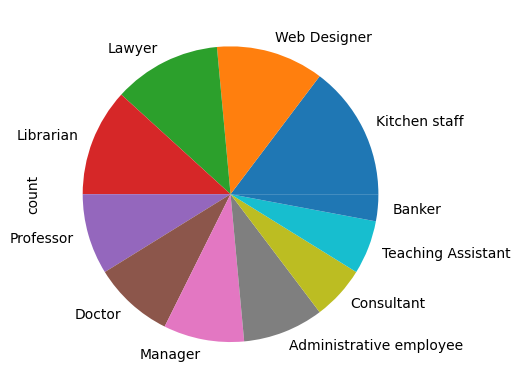

In [ ]:
#Your code here
US_travels["employment"].value_counts().plot.pie(autopct="")
plt.show()

**Q8. Which profession is the least represented among the suspects who traveled to US between September 1st, 2019, and October 31st, 2020?**
 Choose from the answers on Moodle.


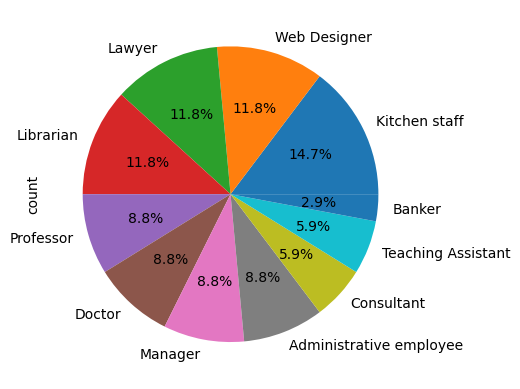

In [ ]:
US_travels["employment"].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [ ]:
print(US_travels["employment"].value_counts().idxmin())

Banker


In [ ]:
print(US_travels["employment"].value_counts())

employment
Kitchen staff              5
Web Designer               4
Lawyer                     4
Librarian                  4
Professor                  3
Doctor                     3
Manager                    3
Administrative employee    3
Consultant                 2
Teaching Assistant         2
Banker                     1
Name: count, dtype: int64


## Journey length

The Suisse Impossible Mission Force suspects that the rogue agent is an anomaly within his declared employment category, particularly in terms of the number of days he spent at destinations compared to his peers.

To identify such deviations, we can employ boxplots for each employment category, allowing us to visually identify outliers in the data.

First, let's construct two tables: one for the dates of arrival and another for the dates of departure. Utilize the existing dataset to extract these dates based on the 'destination' and 'departure' columns. Ensure that both the arrival and departure dates are within the period the suspect is believed to have been in the US, which is from September 2019 to October 2020.

In [ ]:
# For this step we will need the information not only about the fights to the US,
# but also about the flights taken from the US
# Your code here
mergedRecords["date"] = pd.to_datetime(mergedRecords["date"], format="%d.%m.%y")
début = "2019-09-01"
fin = "2020-10-31"
arrivées = mergedRecords[(mergedRecords["destination"] == "US") & (mergedRecords["date"].between(début, fin))]
départs = mergedRecords[(mergedRecords["departure"] == "US") & (mergedRecords["date"].between(début, fin))]

print(len(arrivées))
print(len(départs))

34
33


We can keep on both of these tables the user ID, employment, and departure date / arrival date.

In [ ]:
#Your code here
arrivées = arrivées[["UserID", "employment", "date"]]
départs = départs[["UserID", "employment", "date"]]
print(arrivées)
print(départs)

       UserID               employment       date
246    468560                   Lawyer 2020-07-16
463    255830                Professor 2020-04-10
958    861915                   Doctor 2020-02-10
2289   220420             Web Designer 2020-03-17
2702   297653                   Lawyer 2020-07-23
4089   710764                  Manager 2019-09-17
4897   267733            Kitchen staff 2020-10-10
5349   429697  Administrative employee 2020-06-26
7179   649131                   Banker 2020-04-18
7451   481578  Administrative employee 2020-05-03
7588   434361            Kitchen staff 2020-10-06
7665   804662               Consultant 2020-01-14
7913   287607            Kitchen staff 2020-02-16
8452   411537             Web Designer 2020-08-19
8979   424791       Teaching Assistant 2020-09-20
9623   679196                Librarian 2020-01-23
9990   410319                   Lawyer 2020-04-23
12165  556033             Web Designer 2019-10-13
14639  139646                   Doctor 2019-11-10


We can now join the two tables on user ID.

In [ ]:
#Your code here
travel = pd.merge(arrivées, départs, on="UserID")
print(travel)

    UserID             employment_x  date_dt_x             employment_y  \
0   255830                Professor 2020-04-10                Professor   
1   710764                  Manager 2019-09-17                  Manager   
2   481578  Administrative employee 2020-05-03  Administrative employee   
3   804662               Consultant 2020-01-14               Consultant   
4   287607            Kitchen staff 2020-02-16            Kitchen staff   
5   424791       Teaching Assistant 2020-09-20       Teaching Assistant   
6   679196                Librarian 2020-01-23                Librarian   
7   556033             Web Designer 2019-10-13             Web Designer   
8   139646                   Doctor 2019-11-10                   Doctor   
9   628854                  Manager 2020-07-29                  Manager   
10  762279                   Doctor 2019-09-20                   Doctor   
11  638911            Kitchen staff 2020-01-09            Kitchen staff   
12  428951            Kit

We can now create a new feature called journey_length representing the difference between departure date and arrival date.

*Hint: Ensure that the journey_length is in the right format*

In [ ]:
#Your code here
travel["date_dt_x"] = pd.to_datetime(travel["date_dt_x"])
travel["date_dt_y"] = pd.to_datetime(travel["date_dt_y"])
travel["journey_length"] = (travel["date_dt_y"] - travel["date_dt_x"]).dt.days
travel = travel[travel["journey_length"] > 0]
print(travel)

    UserID             employment_x  date_dt_x             employment_y  \
0   255830                Professor 2020-04-10                Professor   
1   710764                  Manager 2019-09-17                  Manager   
2   481578  Administrative employee 2020-05-03  Administrative employee   
3   804662               Consultant 2020-01-14               Consultant   
4   287607            Kitchen staff 2020-02-16            Kitchen staff   
5   424791       Teaching Assistant 2020-09-20       Teaching Assistant   
6   679196                Librarian 2020-01-23                Librarian   
7   556033             Web Designer 2019-10-13             Web Designer   
8   139646                   Doctor 2019-11-10                   Doctor   
9   628854                  Manager 2020-07-29                  Manager   
10  762279                   Doctor 2019-09-20                   Doctor   
11  638911            Kitchen staff 2020-01-09            Kitchen staff   
12  428951            Kit

*Sidenote: if you get negative journey length, what would be your explanation to that?*

We can now create the boxplots where the x-axis represents each profession and the y-axis corresponds to the journey length.

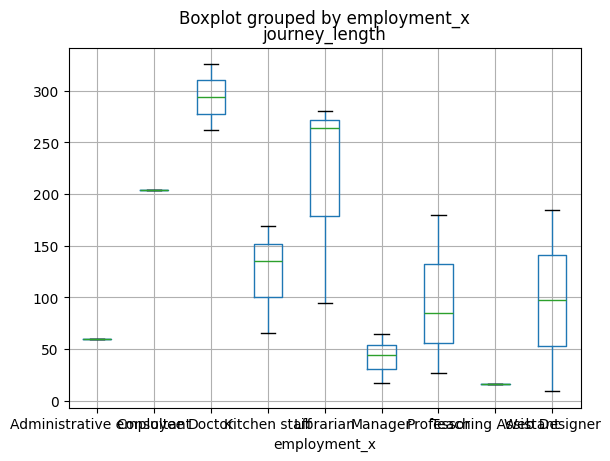

In [ ]:
#Your code here
travel.boxplot(column="journey_length", by="employment_x")
plt.show()

**Q9. Which profession has the most staggering outlier?**
(Meaning that the outlier value is the farthest away from the corresponding boxplot.)

In [ ]:
print(travel.groupby("employment_x")["journey_length"].agg(["min", "max", "mean"]))

                         min  max        mean
employment_x                                 
Administrative employee   60   60   60.000000
Consultant               204  204  204.000000
Doctor                   262  326  294.000000
Kitchen staff             65  169  123.000000
Librarian                 94  280  212.666667
Manager                   17   64   41.666667
Professor                 27  180   97.333333
Teaching Assistant        16   16   16.000000
Web Designer               9  185   97.000000


### SIMF is satisfied with your work but believes the current data is inconclusive.

Your investigation will continue when more intelligence comes in...

**Don't forget to complete the moodle quiz ([Assignment Q1](https://moodle.unil.ch/mod/quiz/view.php?id=1744562)) and submit your code ([Code Q1](https://moodle.unil.ch/mod/assign/view.php?id=1744563)) on Moodle before Monday 30.09.2024.**